# Sample script for plotting vertical profiles of observed variables

## Required packages
- numpy
- matplotlib

In [1]:
from bsod2 import Sondeset
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Read observational data and perform quality control.

In [2]:
raw_data_dir = Path("Seisuimaru2407/raw_data")  # raw data directory
ss = Sondeset(raw_data_dir,interp="z")

ss

100%|██████████| 8/8 [00:04<00:00,  1.81it/s]


Sondeset(fpath=PosixPath('Seisuimaru2407/raw_data'), rm_descending=False, interp='z', interp_pmin=50.0, interp_pmax=1100.0, interp_dp=1.0, interp_zmin=0.0, interp_zmax=20000.0, interp_dz=10.0, kwargs=None)

## Plot vertical profiles

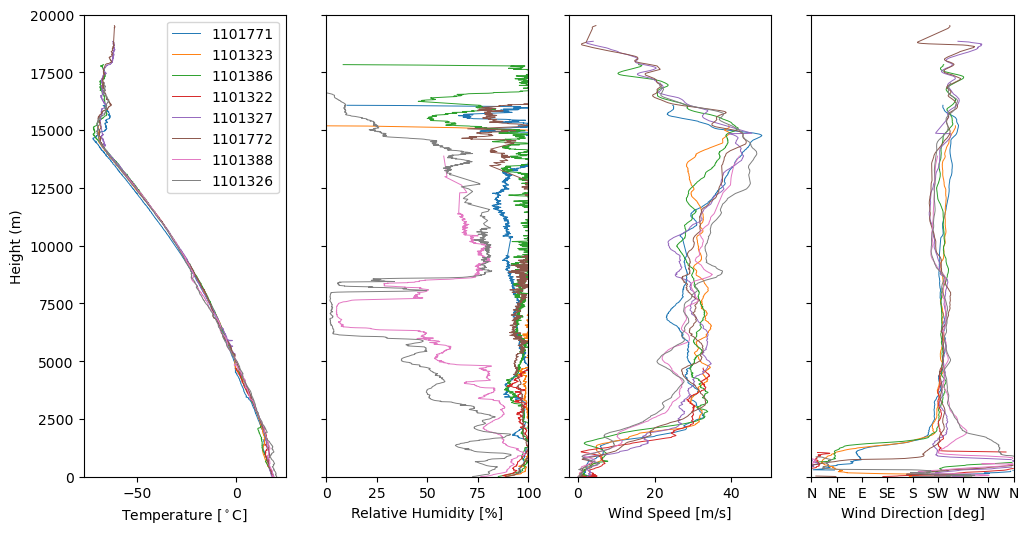

In [3]:
ZMIN, ZMAX = 0, 2e4     # range of height to plot

color_dict = {}
for i,n in enumerate(ss.sonde_no):
    color_dict[n] =plt.rcParams['axes.prop_cycle'].by_key()['color'][i] 


fig,axes = plt.subplots(1,4,sharey=True,figsize=(12,6))

axes[0].set_ylim(ZMIN, ZMAX)
axes[0].set_ylabel("Height (m)")

# temperature
axes[0].set_xlabel(r"Temperature [$^\circ$C]")
for sonde in ss:
    axes[0].plot(sonde.t, sonde.z, label=sonde.sonde_no, lw=0.7, color=color_dict[sonde.sonde_no])
    axes[0].legend(loc="upper right")

# relative humidity
axes[1].set_xlabel("Relative Humidity [%]")
axes[1].set_xlim(0, 100)
for sonde in ss:
    axes[1].plot(sonde.rh, sonde.z, label=sonde.sonde_no, lw=0.7, color=color_dict[sonde.sonde_no])

# WS
axes[2].set_xlabel("Wind Speed [m/s]")
for sonde in ss:
    axes[2].plot(sonde.ws, sonde.z, label=sonde.sonde_no,lw=0.7, color=color_dict[sonde.sonde_no])

# WD
axes[3].set_xlabel("Wind Direction [deg]")
axes[3].set_xlim(0, 360)
axes[3].set_xticks(np.arange(0, 361, 45))
axes[3].set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"])
for sonde in ss:
    # split the WD at discontinuous points
    wd = sonde.wd.m.copy()
    z = sonde.z.m.copy()
    split_idx = np.where(np.abs(np.diff(wd)) > 90)[0]+1
    wd_split = np.split(wd, split_idx)
    z_split = np.split(z, split_idx)
    for wd_part, z_part in zip(wd_split, z_split):
        axes[3].plot(wd_part, z_part, label=sonde.sonde_no, lw=0.7, color=color_dict[sonde.sonde_no])

plt.show()